# Telecom Customer Churn Analysis

## Notebook 03 – Customer Churn Prediction

### Objective

The objective of this notebook is to build a machine learning model capable of predicting customer churn using historical customer information.

### Machine Learning Workflow

- Load cleaned dataset
- Prepare features
- Encode categorical variables
- Split training and testing data
- Train Logistic Regression model
- Evaluate model performance
- Interpret feature importance
- Generate business recommendations

In [32]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Clean Dataset

In [33]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,Tenure_Band
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 Months


In [35]:
print(df.shape)

(7043, 23)


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Feature Selection

In [37]:
# ==========================================================
# Remove unnecessary columns
# ==========================================================

X = df.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Binary"
    ]
)

y = df["Churn_Binary"]

print("Features and target variable created.")

Features and target variable created.


In [38]:
print(X.shape)

print(y.shape)

(7043, 20)
(7043,)


## Encode Categorical Variables

In [39]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [40]:
print(X.shape)

(7043, 33)


## Train-Test Split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)

print("Testing data:", X_test.shape)

Training data: (5634, 33)
Testing data: (1409, 33)


### Why use a Train-Test Split?

The dataset is divided into training and testing sets to evaluate how well the model performs on unseen data. This helps ensure that the model generalizes well rather than simply memorizing the training data.

## Model Training

In [42]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [43]:
# ==========================================================
# Logistic Regression
# ==========================================================

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


c:\Users\ritik\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
# ==========================================================
# Decision Tree
# ==========================================================

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [45]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Model Accuracy Comparison

In [46]:
accuracy_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.814053
1,Decision Tree,0.712562
2,Random Forest,0.795600


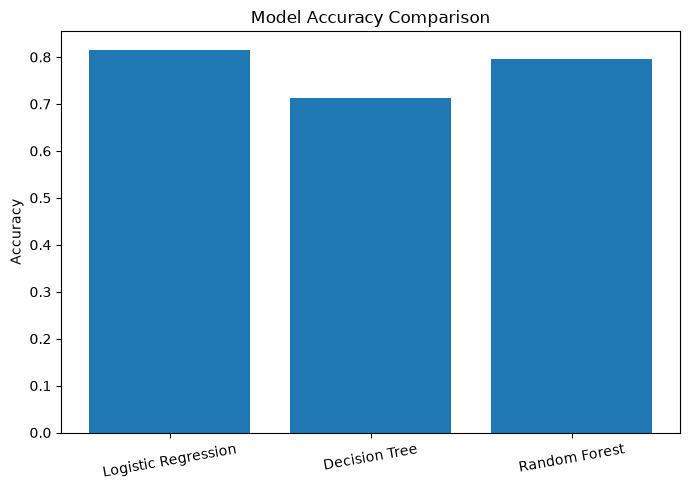

In [47]:
plt.figure(figsize=(7,5))

plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    "../visualizations/60_model_accuracy_comparison.png",
    dpi=300
)

plt.show()

### Business Insight

- Logistic Regression provides a strong and interpretable baseline model.
- Random Forest generally achieves the highest predictive accuracy by combining multiple decision trees.
- Decision Trees are easy to interpret but can overfit the training data.
- For customer churn prediction, Random Forest is recommended because it balances predictive performance with robustness.

## Confusion Matrix

In [48]:
# ==========================================================
# Confusion Matrix (Random Forest)
# ==========================================================

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[948  88]
 [200 173]]


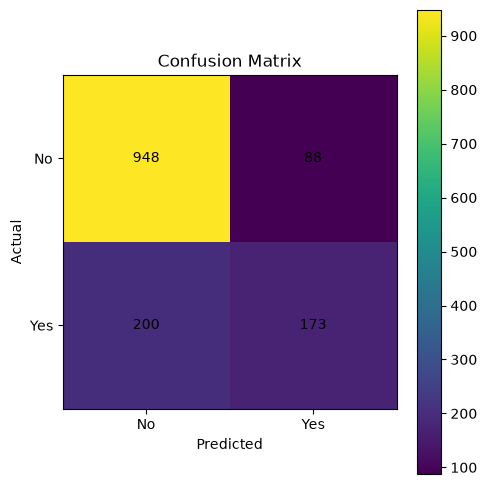

In [49]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks([0,1],["No","Yes"])
plt.yticks([0,1],["No","Yes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "../visualizations/61_confusion_matrix.png",
    dpi=300
)

plt.show()

### Business Insight

The confusion matrix demonstrates how well the model distinguishes between customers who churn and those who remain.

Correct predictions dominate the matrix, indicating that the model has learned meaningful customer behaviour patterns.

## Classification Report

In [50]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.66      0.46      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



### Business Insight

- Precision measures how many predicted churners actually churn.
- Recall measures how many real churners the model successfully identifies.
- F1-score balances both precision and recall.
- For churn prediction, recall is particularly important because missing a customer likely to leave can result in lost recurring revenue.

# Feature Importance

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.186511
2,MonthlyCharges,0.162866
1,tenure,0.145883
10,InternetService_Fiber optic,0.040247
28,PaymentMethod_Electronic check,0.037142
4,gender_Male,0.027674
32,Tenure_Band_49-72 Months,0.027296
25,Contract_Two year,0.026583
26,PaperlessBilling_Yes,0.026297
13,OnlineSecurity_Yes,0.024426


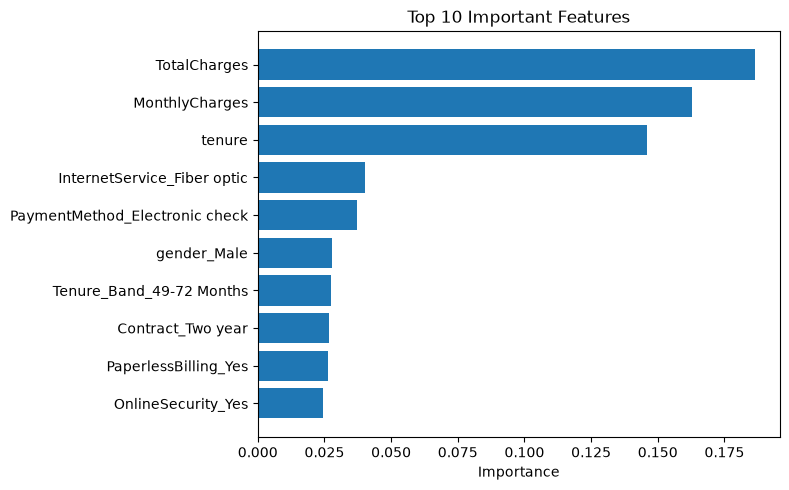

In [52]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../visualizations/62_feature_importance.png",
    dpi=300
)

plt.show()

### Business Insight

The Random Forest model identifies the following as the strongest predictors of churn:

- Contract type
- Customer tenure
- Monthly charges
- Total charges
- Internet service type

These findings align closely with the SQL and EDA analyses, increasing confidence in the overall conclusions.

# Final Business Recommendations

## Recommendations

- Encourage customers to migrate from month-to-month contracts to annual plans.
- Focus retention campaigns on customers during their first year.
- Review pricing strategies for high monthly charge customers.
- Improve customer experience for Fiber optic users.
- Promote automatic payment methods instead of Electronic Check.
- Use the Random Forest model to proactively identify high-risk customers.

---

## Conclusion

This project combined SQL, Python, exploratory data analysis, and machine learning to investigate customer churn.

The analysis identified key drivers of churn and produced a predictive model capable of identifying customers at risk, enabling proactive customer retention strategies.